In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from utils import bs_call, bs_put
from quantum_pricing_utils import price_Eurocall, price_Europut

# Quantify error evolution 

In [2]:
S0 = 100
r = 0.045
sigma = 0.25

c = 0.25
n_qubits = 3

In [3]:
K = np.linspace(50, 180, 25)
T = np.linspace(0.1, 3.0, 25)

In [4]:
abs_errors_call, abs_errors_put = [], []
rel_errors_call, rel_errors_put = [], []

eps = 1e-12  # pour éviter division par zéro

for k in K:

    t = 1.0

    q_call = price_Eurocall(S0, k, r, sigma, t, n_qubits, c)
    q_put  = price_Europut(S0, k, r, sigma, t, n_qubits, c) 

    call = bs_call(S0, k, sigma, r, t)
    put  = bs_put(S0, k, sigma, r, t)

    abs_error_c = abs(q_call - call)
    abs_error_p = abs(q_put - put)

    abs_errors_call.append(abs_error_c)
    abs_errors_put.append(abs_error_p)

    # erreurs relatives
    rel_error_c = abs_error_c / (abs(call) + eps)
    rel_error_p = abs_error_p / (abs(put) + eps)

    rel_errors_call.append(rel_error_c)
    rel_errors_put.append(rel_error_p)

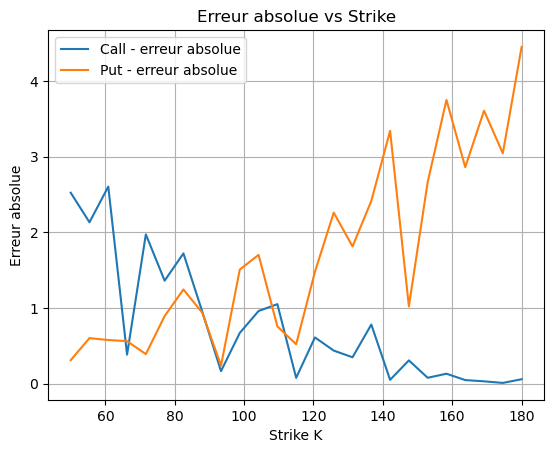

In [5]:
plt.figure()
plt.plot(K, abs_errors_call, label="Call - erreur absolue")
plt.plot(K, abs_errors_put, label="Put - erreur absolue")

plt.xlabel("Strike K")
plt.ylabel("Erreur absolue")
plt.title("Erreur absolue vs Strike")
plt.legend()
plt.grid(True)

plt.show()

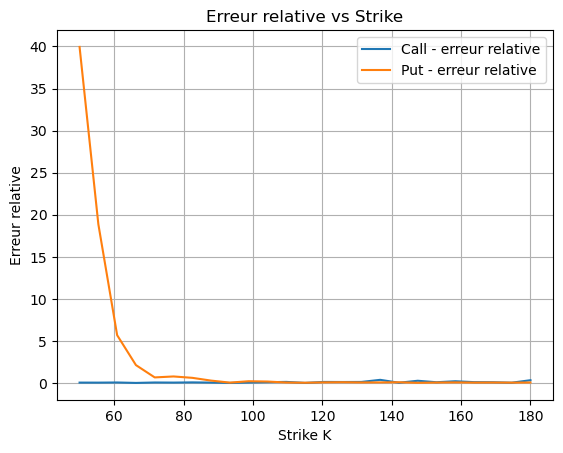

In [6]:
plt.figure()
plt.plot(K, rel_errors_call, label="Call - erreur relative")
plt.plot(K, rel_errors_put, label="Put - erreur relative")

plt.xlabel("Strike K")
plt.ylabel("Erreur relative")
plt.title("Erreur relative vs Strike")
plt.legend()
plt.grid(True)

plt.show()

In [7]:
abs_errors_call, abs_errors_put = [], []
rel_errors_call, rel_errors_put = [], []

eps = 1e-12  # pour éviter division par zéro

for t in T :

    k = 100

    q_call = price_Eurocall(S0, k, r, sigma, t, 3, c)
    q_put  = price_Europut(S0, k, r, sigma, t, 3, c) 

    call = bs_call(S0, k, sigma, r, t)
    put  = bs_put(S0, k, sigma, r, t)

    abs_error_c = abs(q_call - call)
    abs_error_p = abs(q_put - put)

    abs_errors_call.append(abs_error_c)
    abs_errors_put.append(abs_error_p)

    # erreurs relatives
    rel_error_c = abs_error_c / (abs(call) + eps)
    rel_error_p = abs_error_p / (abs(put) + eps)

    rel_errors_call.append(rel_error_c)
    rel_errors_put.append(rel_error_p)

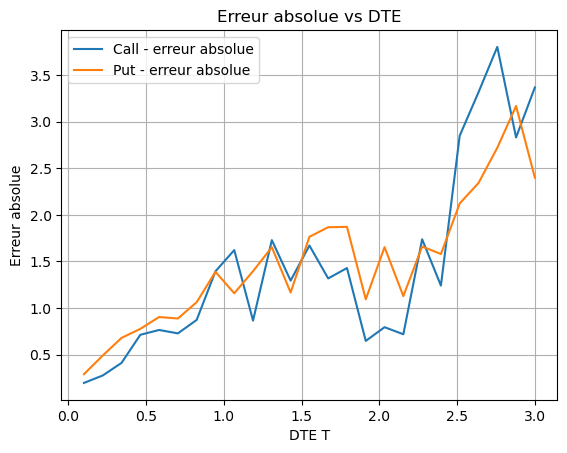

In [8]:
plt.figure()
plt.plot(T, abs_errors_call, label="Call - erreur absolue")
plt.plot(T, abs_errors_put, label="Put - erreur absolue")

plt.xlabel("DTE T")
plt.ylabel("Erreur absolue")
plt.title("Erreur absolue vs DTE")
plt.legend()
plt.grid(True)

plt.show()

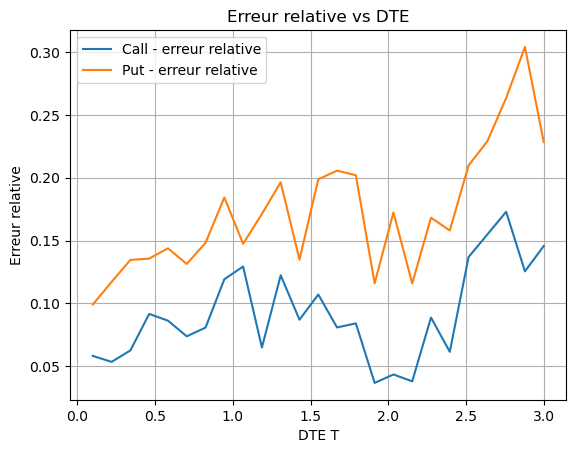

In [9]:
plt.figure()
plt.plot(T, rel_errors_call, label="Call - erreur relative")
plt.plot(T, rel_errors_put, label="Put - erreur relative")

plt.xlabel("DTE T")
plt.ylabel("Erreur relative")
plt.title("Erreur relative vs DTE")
plt.legend()
plt.grid(True)

plt.show()

In [10]:
abs_errors_call, abs_errors_put = [], []
rel_errors_call, rel_errors_put = [], []

eps = 1e-12  # pour éviter division par zéro

vols = np.linspace(0.1, 0.6, 25)

for s in vols :

    k = 100
    t = 1.0

    q_call = price_Eurocall(S0, k, r, s, t, 3, c)
    q_put  = price_Europut(S0, k, r, s, t, 3, c) 

    call = bs_call(S0, k, s, r, t)
    put  = bs_put(S0, k, s, r, t)

    abs_error_c = abs(q_call - call)
    abs_error_p = abs(q_put - put)

    abs_errors_call.append(abs_error_c)
    abs_errors_put.append(abs_error_p)

    # erreurs relatives
    rel_error_c = abs_error_c / (abs(call) + eps)
    rel_error_p = abs_error_p / (abs(put) + eps)

    rel_errors_call.append(rel_error_c)
    rel_errors_put.append(rel_error_p)

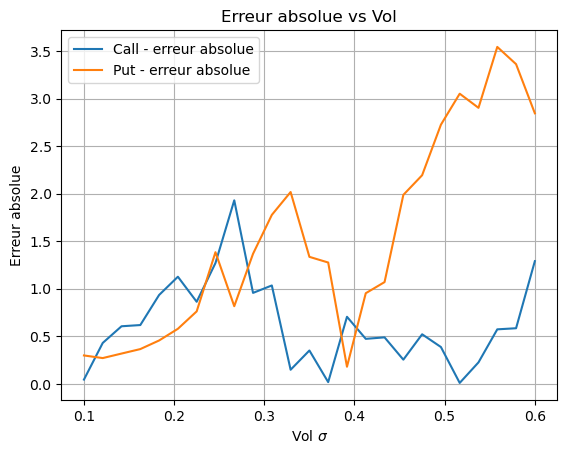

In [11]:
plt.figure()
plt.plot(vols, abs_errors_call, label="Call - erreur absolue")
plt.plot(vols, abs_errors_put, label="Put - erreur absolue")

plt.xlabel("Vol $\sigma$")
plt.ylabel("Erreur absolue")
plt.title("Erreur absolue vs Vol")
plt.legend()
plt.grid(True)

plt.show()

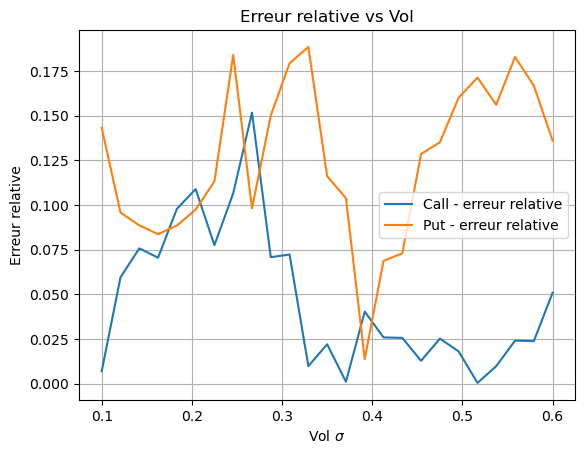

In [ ]:
plt.figure()
plt.plot(vols, rel_errors_call, label="Call - erreur relative")
plt.plot(vols, rel_errors_put, label="Put - erreur relative")

plt.xlabel("Vol $\sigma$")
plt.ylabel("Erreur relative")
plt.title("Erreur relative vs Vol")
plt.legend()
plt.grid(True)

plt.show()